# Global AI Job Market Exploratory Data Analysis

Understanding salary trends, experience requirements, remote work adoption, and industry patterns in the AI job market.

## Exploratory Data Analysis (EDA)

## Project Summary

Artificial Intelligence is transforming industries worldwide and creating significant demand for AI-related professionals. This project explores the Global AI Job Market & Salary Insights 2025 dataset to understand hiring trends, salary distributions, skill requirements, work arrangements, and geographical patterns in the AI industry.

Through Exploratory Data Analysis (EDA), the project aims to uncover meaningful insights that can help job seekers, students, recruiters, and organizations understand the current AI employment landscape and make data-driven decisions.

## Objectives

- Understand the structure and quality of the dataset.
- Perform data cleaning and preprocessing.
- Analyze salary trends across different job roles.
- Identify the most in-demand AI skills.
- Compare salaries across countries and experience levels.
- Analyze remote, hybrid, and onsite work trends.
- Discover patterns, correlations, and anomalies in the AI job market.
- Generate actionable insights through data visualization.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab



###**Executive Summary**

After analyzing the Global AI Job Market & Salary Insights 2025 dataset, several interesting trends were identified regarding salaries, experience levels, skills, and work arrangements in the AI industry.

The analysis shows that experience plays a major role in salary growth, with experienced professionals generally earning higher salaries than those at entry-level positions. The results also indicate that remote, hybrid, and onsite jobs follow relatively similar salary patterns.

Another interesting finding is that having a larger number of listed skills does not necessarily lead to higher pay. Instead, employers appear to value relevant experience and specialized expertise more strongly.

Overall, the dataset provides valuable insights into current hiring trends and compensation patterns in the AI job market, helping job seekers and professionals better understand the skills and experience that are most valued by employers.


In [1]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/ai_job_dataset.csv')

In [3]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


### **Dataset Understanding**

In this section, we examine the structure of the dataset, including the number of records, features, data types, missing values, and basic statistical information. Understanding the dataset is essential before performing data cleaning and analysis.

In [4]:
df.shape

(15000, 19)

The dataset contains 15000 rows and 19 columns.

In [5]:
df.columns

Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='object')

#### Observation
The dataset contains columns such as:

job_id - Unique identifier for each job posting

job_title - Title/role advertised

salary_usd - Annual salary converted to USD

salary_currency - Currency in which salary is offered

experience_level - Level of experience required (EN=Entry, MI=Mid, SE=Senior, EX=Executive)

employment_type - Contract type (CT = Contract, FT = Full-time, PT = Part-time, FL = Freelance)

company_location - Country where the company is based

company_size - Company size (S = Small, M = Medium, L = Large)

employee_residence - Country of employee residence

remote_ratio - Percentage of remote work allowed (0 = Onsite, 50 = Hybrid, 100 = Remote)

required_skills - Key technical skills required (comma-separated)

education_required - Minimum education level required

years_experience - Minimum years of experience required

industry - Industry sector of the job

posting_date - Date when the job was posted (YYYY-MM-DD)

application_deadline - Last date to apply for the job (YYYY-MM-DD)

job_description_length - Length of job description in characters

benefits_score - Numeric score (0–10) reflecting benefits quality

company_name - Name of the hiring company

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [7]:
df.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


#### Observation
The statistical summary provides information such as mean, minimum, maximum, and standard deviation values, helping identify data distribution and potential outliers.

### **Data Cleaning and Preprocessing**

Data cleaning is an essential step in the data analysis process. In this section, we verify data quality, identify duplicate records, validate data formats, and prepare the dataset for analysis.

In [8]:
df.isnull().sum()

,0
job_id,0
job_title,0
salary_usd,0
salary_currency,0
experience_level,0
employment_type,0
company_location,0
company_size,0
employee_residence,0
remote_ratio,0


In [9]:
df.duplicated().sum()

np.int64(0)

#### Data Quality Summary

The dataset was found to be clean and well-structured, with no significant missing values or duplicate records. This ensures that the analysis results are reliable and suitable for further exploration.

In [10]:
df['experience_level'].unique()

array(['SE', 'EN', 'MI', 'EX'], dtype=object)

In [11]:
df['employment_type'].unique()

array(['CT', 'FL', 'PT', 'FT'], dtype=object)

In [12]:
df['education_required'].unique()

array(['Bachelor', 'Master', 'Associate', 'PhD'], dtype=object)

In [13]:
df['industry'].unique()

array(['Automotive', 'Media', 'Education', 'Consulting', 'Healthcare',
       'Gaming', 'Government', 'Telecommunications', 'Manufacturing',
       'Energy', 'Technology', 'Real Estate', 'Finance', 'Transportation',
       'Retail'], dtype=object)

In [14]:
# posting_date and application_deadlin columns are object type that convert into date.
df['posting_date'] = pd.to_datetime(df['posting_date'])
df['application_deadline'] = pd.to_datetime(df['application_deadline'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   job_id                  15000 non-null  object        
 1   job_title               15000 non-null  object        
 2   salary_usd              15000 non-null  int64         
 3   salary_currency         15000 non-null  object        
 4   experience_level        15000 non-null  object        
 5   employment_type         15000 non-null  object        
 6   company_location        15000 non-null  object        
 7   company_size            15000 non-null  object        
 8   employee_residence      15000 non-null  object        
 9   remote_ratio            15000 non-null  int64         
 10  required_skills         15000 non-null  object        
 11  education_required      15000 non-null  object        
 12  years_experience        15000 non-null  int64 

In [16]:
df['remote_ratio'].value_counts()

,count
remote_ratio,
0,5075
50,5005
100,4920


In [17]:
# save clean dataset
df.to_csv('ai_job_market.csv', index=False)

### **Exploratory Data Analysis**

In this section, different aspects of the AI job market are explored to better understand salary trends, experience requirements, work arrangements, industry demand, and required skills. The goal is to identify useful patterns and insights that can help explain the current state of the AI job market.


1. Which Experience Level Has The Most Job Openings?

In [18]:
experience_counts = df['experience_level'].value_counts()
experience_counts

,count
experience_level,
MI,3781
EX,3760
SE,3741
EN,3718


#### Observation
Job openings are fairly balanced across all experience levels, with executive-level roles showing slightly higher demand. The results indicate a strong need for experienced AI professionals in the current job market.


2. Does Remote Work Increase Salary?

In [19]:
df.groupby('remote_ratio')['salary_usd'].mean()

,salary_usd
remote_ratio,
0,114140.231133
50,115776.806793
100,116160.545935


####Observation

The average salary remains fairly consistent across onsite, hybrid, and remote jobs. While onsite roles show a slightly higher average salary, the difference is not significant.

####Insight

This suggests that remote work does not necessarily lead to higher pay. Factors such as experience level, job role, and industry appear to have a greater influence on salary than work arrangement.

Remote work has become increasingly common in the AI industry. A common assumption is that professionals working remotely receive higher salaries than those working in hybrid or on-site roles.

To verify whether this assumption is supported by the data, a statistical hypothesis test was conducted to compare salaries across different work arrangements.

The analysis focuses on determining whether differences in average salaries are statistically significant or simply due to random variation in the dataset.


In [20]:
from scipy.stats import f_oneway

remote_salary = df[df['remote_ratio'] == 100]['salary_usd']
hybrid_salary = df[(df['remote_ratio'] > 0) & (df['remote_ratio'] < 100)]['salary_usd']
onsite_salary = df[df['remote_ratio'] == 0]['salary_usd']

f_statistic, p_value = f_oneway(
    remote_salary,
    hybrid_salary,
    onsite_salary
)

print("F-Statistic:", round(f_statistic, 4))
print("P-Value:", round(p_value, 6))

F-Statistic: 1.5934
P-Value: 0.203268


#### Interpretation

The calculated p-value is greater than the significance level of 0.05.

Therefore, the null hypothesis cannot be rejected.

The analysis does not provide sufficient statistical evidence to conclude that average salaries differ significantly across remote, hybrid, and on-site work arrangements.

Although salary differences may appear in visualizations, those differences are not statistically strong enough to confirm a meaningful relationship in this dataset.


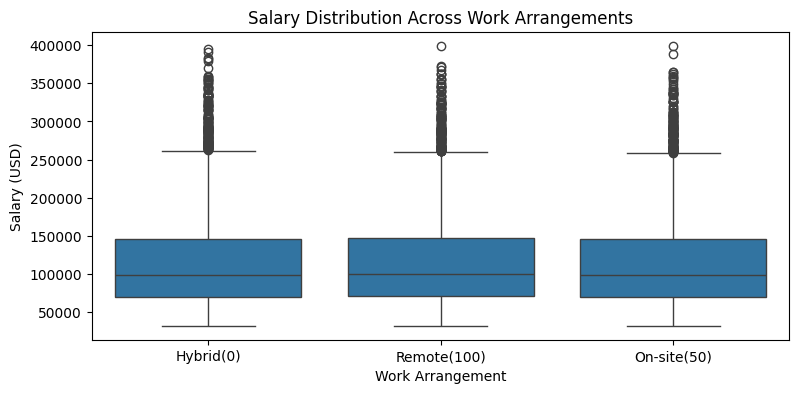

In [21]:
work_type = []

for value in df['remote_ratio']:
    if value == 100:
        work_type.append('Remote(100)')
    elif value == 0:
        work_type.append('On-site(50)')
    else:
        work_type.append('Hybrid(0)')

df['work_type'] = work_type

plt.figure(figsize=(9,4))
sns.boxplot(
    data=df,
    x='work_type',
    y='salary_usd'
)

plt.title('Salary Distribution Across Work Arrangements')
plt.xlabel('Work Arrangement')
plt.ylabel('Salary (USD)')
plt.show()

#### Insight

The statistical test provides a more reliable conclusion than visual inspection alone. While charts can suggest patterns, hypothesis testing helps determine whether those patterns are genuinely meaningful.

This analysis strengthens the findings by validating them with statistical evidence rather than relying solely on observations from visualizations.


3. Which industries prefer remote work?

In [22]:
pd.crosstab(df['industry'],df['remote_ratio'])

remote_ratio,0,50,100
industry,,,
Automotive,345,352,323
Consulting,335,354,331
Education,342,297,317
Energy,335,332,309
Finance,318,332,334
Gaming,327,324,316
Government,346,316,336
Healthcare,336,339,322
Manufacturing,323,329,310


#### Observation and insight

Work arrangement preferences are fairly balanced across industries, with only small differences between remote, hybrid, and onsite roles. This suggests that flexible work options are becoming common across a wide range of industries rather than being limited to specific sectors.


 4. Which industries hire senior talent?

In [23]:
pd.crosstab(df['industry'],df['experience_level'])

experience_level,EN,EX,MI,SE
industry,,,,
Automotive,275,243,249,253
Consulting,245,274,246,255
Education,228,241,257,230
Energy,229,265,258,224
Finance,245,247,249,243
Gaming,267,234,245,221
Government,227,248,271,252
Healthcare,252,257,250,238
Manufacturing,242,236,211,273


#### Observation and Insight

The distribution of experience levels varies across industries, with sectors such as Telecommunications, Consulting, and Technology showing a relatively higher number of senior-level professionals. This suggests that some industries may require more experienced talent to support complex AI and technology-driven projects.


5. Which industries hire freshers?

In [24]:
freshers = df[df['experience_level']=='EN']
freshers.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name,work_type
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc,Remote(100)
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics,Remote(100)
7,AI00008,NLP Engineer,70640,EUR,EN,FL,France,L,France,0,"Python, SQL, Computer Vision, Java, Azure",Master,0,Healthcare,2024-06-07,2024-07-01,1286,7.6,Cloud AI Solutions,On-site(50)
13,AI00014,Autonomous Systems Engineer,68760,USD,EN,CT,Norway,S,Norway,0,"Scala, SQL, Statistics",Master,0,Energy,2024-02-11,2024-02-25,1657,9.1,Cloud AI Solutions,On-site(50)
15,AI00016,AI Product Manager,78846,GBP,EN,PT,United Kingdom,L,Israel,0,"Linux, Statistics, Deep Learning",PhD,0,Consulting,2024-09-28,2024-10-26,2059,9.6,DataVision Ltd,On-site(50)


In [25]:
freshers['industry'].value_counts()

,count
industry,
Retail,276
Automotive,275
Gaming,267
Real Estate,255
Technology,252
Healthcare,252
Media,252
Consulting,245
Finance,245


#### Observation and Insight
The analysis shows that Healthcare and Automotive industries currently offer the highest number of entry-level AI job opportunities, with Consulting and Gaming also providing a significant number of openings. On the other hand, industries such as Energy and Transportation appear to have fewer opportunities available for fresh graduates.

These findings indicate that demand for AI talent is not limited to technology companies alone. Many industries are increasingly adopting AI-driven solutions and are willing to hire early-career professionals, creating a wider range of opportunities for students and recent graduates entering the job market.



6. Is higher education actually worth it?

In [26]:
df.groupby('education_required')['salary_usd'].mean()

,salary_usd
education_required,
Associate,114605.708058
Bachelor,115861.629190
Master,117171.815902
PhD,113728.165579


#### Observation and Insight

The average salary remains fairly consistent across different education levels, with only minor differences between Associate, Bachelor’s, Master’s, and PhD holders. This indicates that earning a higher degree does not necessarily guarantee a significantly higher salary in AI-related roles. Instead, practical experience, specialized skills, and job responsibilities may have a greater influence on compensation.


7. Impact of Company Size on Salaries

In [27]:
# Overall Salaries
df.groupby('company_size')['salary_usd'].mean()

,salary_usd
company_size,
L,130322.451781
M,113600.237037
S,102146.930098


#### Observation and Insight

The analysis shows that large companies pay the highest average salaries, followed by medium-sized and small companies. This may be because larger organizations often have bigger budgets and can invest more in hiring experienced AI professionals.

For individuals exploring career opportunities in AI, company size can be an important factor when evaluating potential salary and growth prospects.


In [28]:
# Entry-Level Salaries
freshers.groupby('company_size')['salary_usd'].mean()

,salary_usd
company_size,
L,71762.011532
M,62233.536783
S,55744.221784


#### Observation and Insight

For entry-level professionals, large companies offer the highest average salaries, followed by medium-sized and small companies. This suggests that larger organizations may provide better compensation and resources for freshers starting their careers in the AI industry.

As a result, large companies could be an attractive option for graduates seeking both learning opportunities and competitive salaries.


8. Which Countries Offer the Highest Average AI Salaries?

In [29]:
country_salary = (
    df.groupby('company_location')['salary_usd'].mean().sort_values(ascending=False).head(10)
)
country_salary

,salary_usd
company_location,
Switzerland,170639.085791
Denmark,165652.249357
Norway,159490.533981
United States,146833.045580
United Kingdom,128720.186557
Singapore,128004.035340
Netherlands,126750.451436
Sweden,123559.753989
Germany,121810.143735


#### Observation and Insight

Denmark, Switzerland, and Norway offer the highest average AI salaries, followed by the United States and the United Kingdom. This indicates that AI professionals in these countries tend to receive higher compensation compared to many other regions.

The results suggest that location can have a significant impact on salary levels, making country selection an important factor for professionals considering international career opportunities.


9. Which Industries Pay Freshers the Most?

In [30]:
industry_fresher_salary = (
    freshers.groupby('industry')['salary_usd'].mean().sort_values(ascending=False)
)

industry_fresher_salary.head(10)

,salary_usd
industry,
Education,64692.250000
Government,64329.101322
Manufacturing,64221.669421
Automotive,63848.883636
Healthcare,63812.305556
Real Estate,63697.913725
Telecommunications,63660.887967
Transportation,63461.840517
Consulting,63265.742857


#### Observation and Insight

For entry-level AI professionals, the highest average salaries are found in the Telecommunications and Government sectors, with Manufacturing and Finance also offering competitive pay. Although the salary differences between industries are not very large, the results show that fresh graduates have good earning opportunities across a variety of fields.

This highlights that AI careers extend well beyond traditional technology companies. Many industries are adopting AI solutions and are willing to invest in new talent, creating diverse career paths for those starting their careers.


### **Correlation Analysis: Understanding Key Salary Drivers**

#### **Why Correlation Analysis?**

While descriptive statistics and visualizations reveal trends within the dataset, correlation analysis helps identify relationships between variables.

Understanding these relationships is useful for determining which factors are most strongly associated with salary levels and career progression in the AI job market.

This analysis focuses on exploring how numerical variables interact and whether any meaningful patterns exist that can support data-driven decision-making.


In [31]:
numerical_columns = df.select_dtypes(include=['int64', 'float64'])

numerical_columns.head()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
0,90376,50,9,1076,5.9
1,61895,100,1,1268,5.2
2,152626,0,2,1974,9.4
3,80215,50,7,1345,8.6
4,54624,100,0,1989,6.6


In [32]:
corr_matrix = numerical_columns.corr()

corr_matrix

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
salary_usd,1.000000,0.013727,0.737556,-0.009092,0.000985
remote_ratio,0.013727,1.000000,0.015321,0.004475,0.003139
years_experience,0.737556,0.015321,1.000000,-0.007526,-0.007275
job_description_length,-0.009092,0.004475,-0.007526,1.000000,0.006744
benefits_score,0.000985,0.003139,-0.007275,0.006744,1.000000


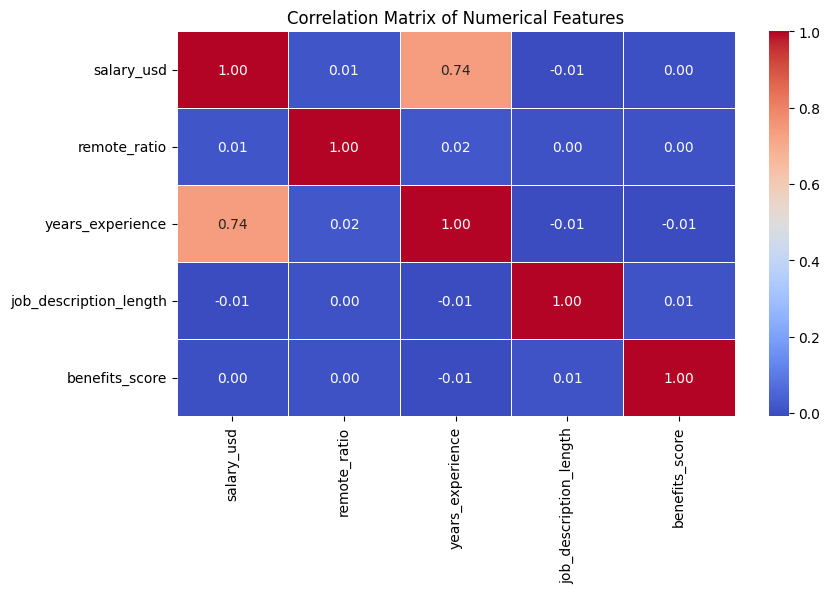

In [33]:
plt.figure(figsize=(9,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

#### **Analysis of Correlation Results**

The correlation matrix provides a broader understanding of how numerical variables are related to one another.

Variables with stronger positive correlation values tend to increase together, while negative correlations indicate that one variable tends to decrease as the other increases.

Particular attention was given to variables associated with salary, as compensation remains one of the most important indicators within the job market.

The analysis helps identify whether factors such as experience, company characteristics, or work arrangements demonstrate measurable relationships with salary outcomes.


In [34]:
salary_corr = corr_matrix['salary_usd'].sort_values(ascending=False)

salary_corr

,salary_usd
salary_usd,1.000000
years_experience,0.737556
remote_ratio,0.013727
benefits_score,0.000985
job_description_length,-0.009092


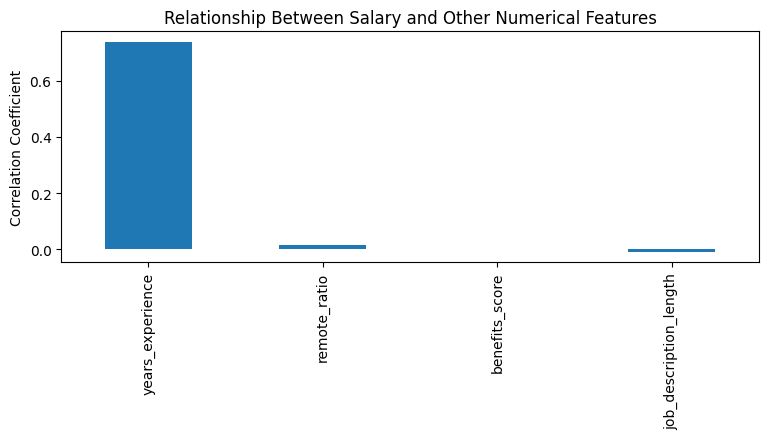

In [35]:
plt.figure(figsize=(9,3))

salary_corr.drop('salary_usd').plot(kind='bar')

plt.title("Relationship Between Salary and Other Numerical Features")
plt.ylabel("Correlation Coefficient")
plt.show()

#### Key Findings

The analysis shows that years of experience has the strongest relationship with salary (correlation = 0.74). This indicates that experienced AI professionals generally earn higher salaries.

Other factors such as remote work ratio, benefits score, job description length, and skill count show very weak correlations with salary, suggesting they have minimal direct influence on compensation within this dataset.

Overall, professional experience appears to be the primary factor associated with salary growth in the AI job market.


#### Insight

The findings suggest that gaining practical experience is one of the most effective ways to increase earning potential in the AI industry. Employers also appear to place greater value on experience than on the number of skills listed by candidates.


###**Advanced Market Intelligence**

**How Does Salary Grow Throughout an AI Career?**

In [36]:
salary_growth = (
    df.groupby('experience_level')['salary_usd']
    .mean()
)

salary_growth

,salary_usd
experience_level,
EN,63133.377084
EX,187723.647340
MI,87955.471833
SE,122187.657845


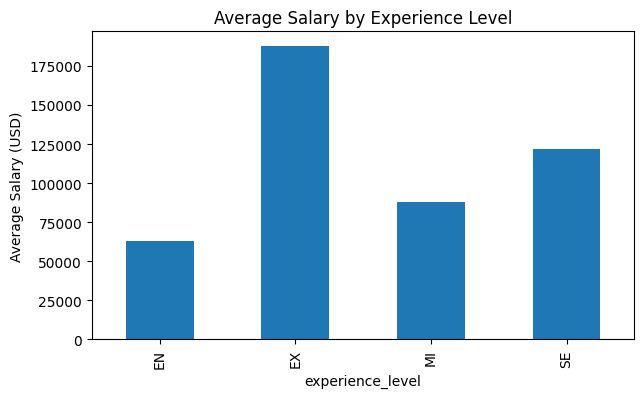

In [37]:
salary_growth.plot(kind='bar',figsize=(7,4))
plt.title("Average Salary by Experience Level")
plt.ylabel("Average Salary (USD)")
plt.show()

#### Observation and Insight

Average salaries increase significantly with experience level. Executive-level professionals earn the highest salaries, followed by senior-level employees, while entry-level positions receive the lowest compensation. This trend suggests that experience remains one of the most important factors influencing salary growth in the AI job market.


**Which AI job roles are most in demand and what salary can freshers expect?**

In [38]:
# Top 10 most demanded job roles

top_demand_jobs = (
    df['job_title'].value_counts().head(10)
)
top_demand_jobs

,count
job_title,
Machine Learning Researcher,808
AI Software Engineer,784
Autonomous Systems Engineer,777
Machine Learning Engineer,772
AI Architect,771
Head of AI,765
NLP Engineer,762
Robotics Engineer,759
Data Analyst,759


In [39]:
# freshers salary for top demand roles

top_roles = top_demand_jobs.index

freshers_salary = (
    freshers[
    freshers['job_title'].isin(top_roles)
    ].groupby('job_title')['salary_usd'].mean().sort_values(ascending=False)
)

freshers_salary

,salary_usd
job_title,
Robotics Engineer,65430.937853
NLP Engineer,64097.994975
Data Analyst,63730.705000
AI Software Engineer,63304.242424
Head of AI,63257.081967
AI Architect,63253.987097
Autonomous Systems Engineer,61752.979058
Machine Learning Researcher,61122.530702
AI Research Scientist,61055.802139


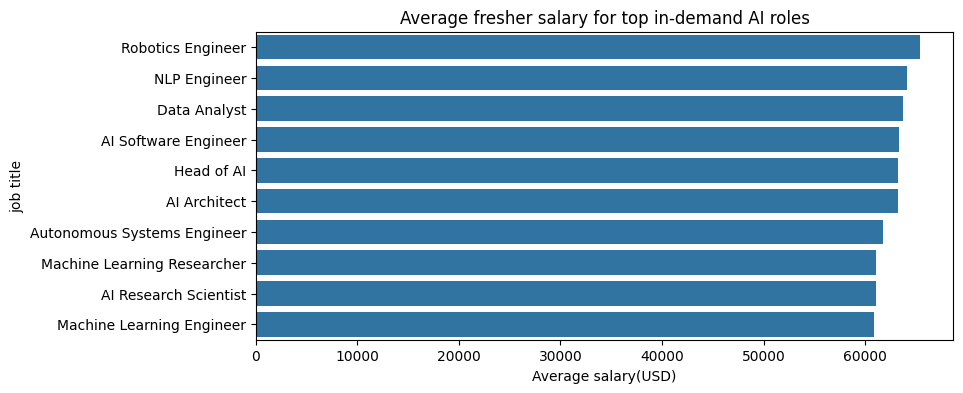

In [40]:
plt.figure(figsize=(9,4))

sns.barplot(
    x = freshers_salary.values,
    y = freshers_salary.index
)

plt.title('Average fresher salary for top in-demand AI roles')
plt.xlabel('Average salary(USD)')
plt.ylabel('job title')

plt.show()

In [41]:
# observation table for top 10 in-demand job role

demand_salary_table = pd.DataFrame({
    'Job Role': top_demand_jobs.index,
    'Total Job Openings': top_demand_jobs.values
})

salary_lookup = (
    freshers.groupby('job_title')['salary_usd']
    .mean()
)

demand_salary_table['Average Fresher Salary (USD)'] = (
    demand_salary_table['Job Role']
    .map(salary_lookup)
)

demand_salary_table

,Job Role,Total Job Openings,Average Fresher Salary (USD)
0,Machine Learning Researcher,808,61122.530702
1,AI Software Engineer,784,63304.242424
2,Autonomous Systems Engineer,777,61752.979058
3,Machine Learning Engineer,772,60845.563218
4,AI Architect,771,63253.987097
5,Head of AI,765,63257.081967
6,NLP Engineer,762,64097.994975
7,Robotics Engineer,759,65430.937853
8,Data Analyst,759,63730.705000
9,AI Research Scientist,756,61055.802139


In [42]:
# Rank jobs by both demand and salary

demand_salary_table = demand_salary_table.sort_values(
    by=['Total Job Openings','Average Fresher Salary (USD)'],
    ascending=False
)

demand_salary_table

,Job Role,Total Job Openings,Average Fresher Salary (USD)
0,Machine Learning Researcher,808,61122.530702
1,AI Software Engineer,784,63304.242424
2,Autonomous Systems Engineer,777,61752.979058
3,Machine Learning Engineer,772,60845.563218
4,AI Architect,771,63253.987097
5,Head of AI,765,63257.081967
6,NLP Engineer,762,64097.994975
7,Robotics Engineer,759,65430.937853
8,Data Analyst,759,63730.705000
9,AI Research Scientist,756,61055.802139


#### Observation
Several AI job roles consistently appear among the most frequently advertised positions. Freshers entering these roles can expect varying salary levels depending on industry and company characteristics.

#### Insight
High-demand roles often provide strong career opportunities for new graduates. Understanding both demand and compensation can help students make informed career decisions.

In [43]:
# Most In-Demand Skills

top_skills = (
    df['required_skills']
      .str.split(',')
      .explode()
      .str.strip()
      .value_counts()
      .head(10)
)

top_skills

,count
required_skills,
Python,4450
SQL,3407
TensorFlow,3022
Kubernetes,3009
Scala,2794
PyTorch,2777
Linux,2705
Git,2631
Java,2578


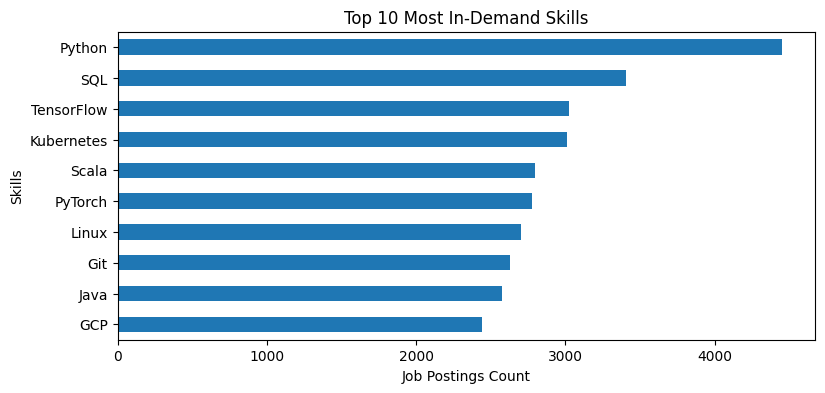

In [44]:
plt.figure(figsize=(9,4))

top_skills.sort_values().plot(kind='barh')

plt.title('Top 10 Most In-Demand Skills')
plt.xlabel('Job Postings Count')
plt.ylabel('Skills')

plt.show()

#### Key Observations and Insights

AI Software Engineer, Autonomous Systems Engineer, and Machine Learning Engineer are among the most demanded roles, showing strong hiring activity in the AI sector.

Data Analyst, NLP Engineer, and AI Architect offer some of the highest average salaries among these roles, making them attractive career options.

Python, TensorFlow, and SQL are the most frequently requested skills, highlighting the importance of programming, machine learning, and data handling in today's AI job market.

Overall, professionals with strong technical skills and relevant experience are likely to have better career opportunities and earning potential.


**High paying industries**

In [45]:
industry_salary = (
    df.groupby('industry')['salary_usd'].mean().sort_values(ascending=False)
)

overall_salary = df['salary_usd'].mean()

industry_salary[industry_salary > overall_salary]

,salary_usd
industry,
Consulting,117602.142157
Manufacturing,116162.888773
Media,116127.730144
Education,116026.803347
Real Estate,115919.095333
Technology,115831.823937
Government,115694.321643


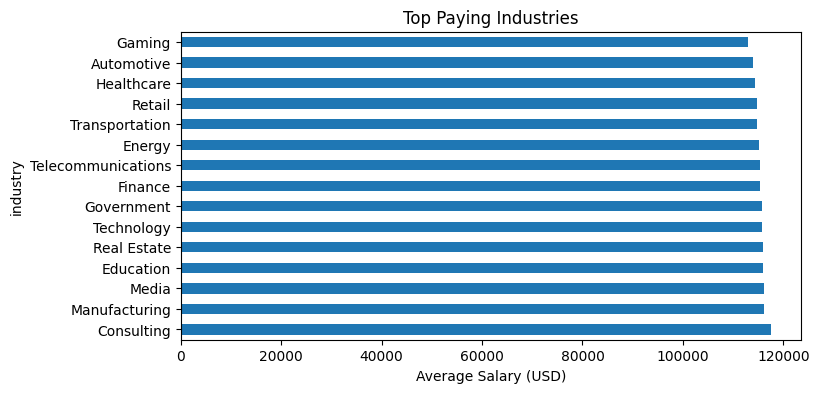

In [46]:
industry_salary.plot(kind='barh',figsize=(8,4))
plt.title("Top Paying Industries")
plt.xlabel("Average Salary (USD)")
plt.show()

#### Observation and Insight

Energy, Real Estate, and Manufacturing emerged as the highest-paying industries for AI professionals in this dataset. The results suggest that demand for AI talent extends beyond the technology sector, with several industries offering competitive salaries to attract skilled professionals.


### **Recommendations**

Based on the findings from this analysis, several practical recommendations can be made for students, job seekers, and professionals interested in AI careers.

* Focus on developing strong technical skills such as Python, SQL, TensorFlow, and cloud technologies, as these are among the most frequently requested skills in AI job postings.

* Gain relevant experience through internships, projects, and certifications, since experience level has a significant impact on salary growth.

* Consider opportunities in large organizations, as they generally offer higher average salaries and better career growth prospects.

* Explore AI opportunities across different industries, including Telecommunications, Finance, Healthcare, Manufacturing, and Government sectors, rather than limiting job searches to technology companies.

* For individuals considering international careers, countries such as Denmark, Switzerland, Norway, and the United States offer some of the highest average AI salaries in the dataset.

These recommendations can help aspiring AI professionals make informed career decisions and better align their skills with current market demands.


## **Conclusion**

In this project, I analyzed the Global AI Job Market & Salary Insights 2025 dataset to understand salary trends, hiring demand, required skills, and work arrangements in the AI industry.

The analysis showed that experience plays an important role in salary growth, while skills such as Python, TensorFlow, and SQL remain highly demanded by employers. Roles like AI Software Engineer, Machine Learning Engineer, and Data Analyst were found to have strong hiring demand across
the market.

Overall, this project provided valuable insights into the current AI job market and helped identify the skills and experience that can improve career opportunities in this field.
